In [112]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from george import kernels
import george
import scipy.optimize as op

In [150]:
def der(xy):
    """
    Compute the numerical derivative of a function given y-values and their corresponding x-values.

    Parameters
    ----------
    xy : array-like, shape (2, N)
        A two-element list or array where:
        - xy[0] contains the y-values,
        - xy[1] contains the corresponding x-values.

    Returns
    -------
    ndarray, shape (2, N-1)
        A two-row array:
        - Row 0: dy/dx (the finite difference derivative),
        - Row 1: midpoints of x (used as the new x positions of the derivative).
    """
    xder, yder = xy[1], xy[0]
    return np.array([np.diff(yder) / np.diff(xder), xder[:-1] + np.diff(xder) * 0.5])


def smoothness_gen(x, y, gp):
    """
    Generate a smoothness penalty term from a GP-predicted function.

    This function applies a second derivative estimate to a Gaussian Process (GP)
    prediction of y-values at positions x, and computes a scalar penalty measuring
    the total curvature or roughness of the prediction.

    Parameters
    ----------
    x : ndarray
        Input x-values.
    y : ndarray
        Observed y-values.
    gp : george.GP
        A Gaussian Process object from the `george` package.

    Returns
    -------
    float
        The total smoothness penalty, computed as the sum of the absolute
        second derivative values of the GP-predicted curve.
    """
    return np.nansum(np.abs(der(der([gp.predict(y, x)[0], x]))), axis=1)[0]
    
def nll(p, y, x, gp, s):
    """
    Compute the negative log-likelihood (NLL) with a smoothness regularization term.

    The function sets the GP kernel parameters, evaluates the likelihood of the
    data under the GP model, and penalizes non-smooth predictions using a tunable
    power-law penalty on second derivatives.

    Parameters
    ----------
    p : ndarray
        The kernel hyperparameter vector to set in the GP.
    y : ndarray
        The observed data values.
    x : ndarray
        The x-values corresponding to `y`.
    gp : george.GP
        A Gaussian Process object from the `george` package.
    s : float
        Smoothness exponent; larger values increase the penalty on rough solutions.

    Returns
    -------
    float
        The negative log-likelihood, regularized by the smoothness term.
        Returns a large penalty (1e25) if numerical instability or NaN is encountered.
    """
    gp.kernel.parameter_vector = p

    try:
        smoothness = smoothness_gen(x, y, gp)
        smoothness = smoothness if np.isfinite(smoothness) \
                                   and ~np.isnan(smoothness) else 1e25
    except np.linalg.LinAlgError:
        smoothness = 1e25

    ll = gp.log_likelihood(y, quiet=True)  # - (smoothness) #np.sum((y - pred[inds]**2)) #
    ll -= smoothness ** s

    # print('smoothness is ', smoothness)

    # print (p, -ll if np.isfinite(ll) else 1e25)
    return -ll if np.isfinite(ll) else 1e25

In [151]:
# Reading an example light curve of a CV
t, m, merr = np.loadtxt('./../lc_example/OGLE-BLG-DN-0001.dat', unpack=True)

In [41]:
# Defining a Gaussian template for the variability in the light curve
x = np.linspace(0,100)
norm_pdf = 25*(norm(loc = 35, scale = 5).pdf(x))

[None, None, None, None, None, None]

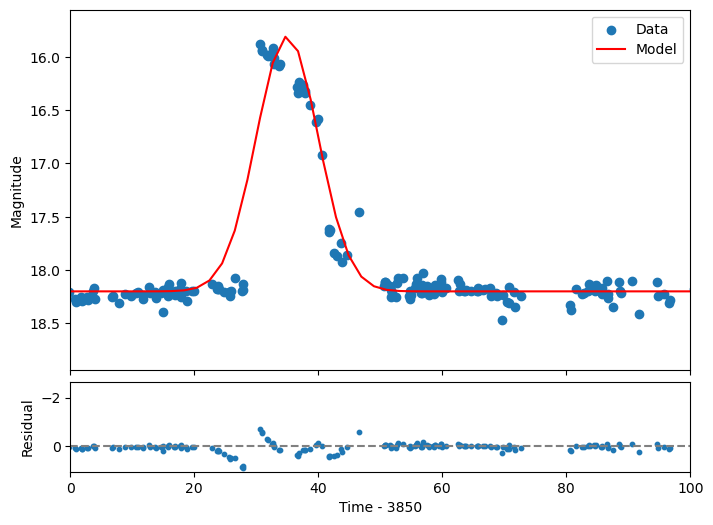

In [152]:
model = -1.2 * norm_pdf + 18.2

# Interpolate model to data points (assuming x and t-3850 are aligned in range)
from scipy.interpolate import interp1d
model_interp = interp1d(x, model, kind='linear', bounds_error=False, fill_value='extrapolate')
residuals = m - model_interp(t - 3850)

# Set up the figure and subplots
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

# Top plot: light curve
ax0 = fig.add_subplot(gs[0])
ax0.scatter(t - 3850, m, label='Data')
ax0.plot(x, model, color='r', label='Model')
ax0.set_xlim(0, 100)
ax0.invert_yaxis()
ax0.legend()
ax0.set_ylabel('Magnitude')

# Bottom plot: residuals
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax1.scatter(t - 3850, residuals, s=10)
ax1.axhline(0, color='gray', linestyle='--')
ax1.set_xlim(0, 100)
ax1.set_ylabel('Residual')
ax1.set_xlabel('Time - 3850')
ax1.invert_yaxis()  # Optional, if you want residuals to be in magnitude scale

# Remove x-axis labels on top plot
plt.setp(ax0.get_xticklabels(), visible=False)

In [154]:
# Defining the GP kernel
kernel = kernels.Product(kernels.ConstantKernel(1.10), kernels.ExpSquaredKernel(1.73))
gp = george.GP(kernel)

In [153]:
# Isolating a single peak in the light curve
ind_fit = ((t - 3850)<100) & ((t - 3850)>0)
t_fit = (t - 3850)[ind_fit]
m_fit = m[ind_fit]
err_fit = merr[ind_fit]
res_fit = residuals[ind_fit]

In [157]:
# Optimizing parameters of the GP
# s determines the smoothness of the fit, larger s= smoother curve
gp.compute(t_fit, err_fit)
p0 = gp.kernel.parameter_vector
s = 2
results = op.minimize(nll, [p0[0], p0[1]],
                      args=(res_fit,
                            t_fit, gp, s))
# Update the kernel and print the final log-likelihood.
gp.kernel.parameter_vector = results.x

In [163]:
# Predicting on a new time sampling
t_fit_new = np.linspace(0,100, 1000)
model_interp_new = model_interp(t_fit_new)
mu, cov = gp.predict(res_fit, t_fit_new)
std = np.sqrt(np.diag(cov))

In [164]:
gp.kernel.parameter_vector

array([-3.75882048,  0.77481128])

Text(0, 0.5, 'Magnitude')

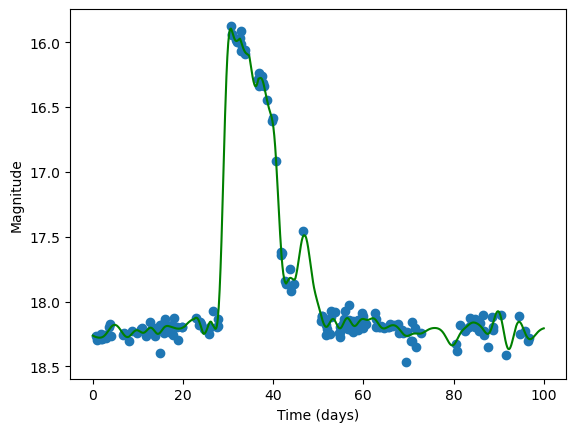

In [165]:
plt.scatter(t_fit, m_fit, label='Data')
plt.plot(t_fit_new, mu+model_interp_new, color='g', label='GP fit')

plt.gca().invert_yaxis()

plt.xlabel('Time (days)')
plt.ylabel('Magnitude')